## Análisis y Procesamiento de Señales, 2C 2026
### Escuela de Ciencia y Tecnología
#### Iara Alvarez Costa
# Tarea Semanal  N°3

En esta tarea semanal se busca analizar el efecto de desparramo espectral.  

Para una senoidal de frecuencia $f_0=k_0.\frac{f_s}{N}=k_0.Δf$, y potencia normalizada, es decir energía (o varianza) unitaria, se pide:

<b>$a)$</b> Sea $k_0$

> - $\frac{N}{4}$
 
> - $\frac{N}{4}. 0,25$
 
> - $\frac{N}{4}. 0,5$
 
Notar que a cada senoidal se le agrega una pequeña desintonía respecto a  Δf. Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

<b>$b)$</b> Verificar la potencia unitaria de cada PSD, puede usar la identidad de Parseval. En base a la teoría estudiada. Discuta la razón por la cual una señal senoidal tiene un espectro tan diferente respecto a otra de muy pocos Hertz de diferencia. 

<b>$c)$</b> Repetir el experimento mediante la técnica de zero padding. Dicha técnica consiste en agregar ceros al final de la señal para aumentar Δf
 de forma ficticia. Probar agregando un vector de $9.N$ ceros al final. Discuta los resultados obtenidos.eñal 

## <u>Introducción</u>

El fenómeno de interés para esta tarea es el desparramo espectral, un fenómeno que se presenta como consecuencia de transformar una señal cuyo periodo no admite un numero entero de ciclos dentro la ventana de tiempo utilizada al aplicar la DFT sobre dicha señal. Si no se ventanea un nro entero de los periodos de la señal, se produce un <i>desparramo</i> de la energía hacia las frecuencias adyacentes, lo cual resulta en una distorsión considerable de su espectro de potencia en el dominio frecuencial.

Para empezar, voy a generar una señal senoidal de media 0 y amplitud $V_{max}= \sqrt{2}$ para asegurar que tenga varianza unitaria. Esta vez no voy a contaminar mi señal con ruido analógico, ya que no forma parte de lo que me interesa analizar.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

"Parámetros de senoidal"
fs = 1000 #Frecuencia muestreo [Hz] 
N = 1000 #Cant. muestras
k1 = N/4
k2 = N/4 + 0.25
k3 = N/4 + 0.5
vmax = np.sqrt(2) #Amp max senoidal
dc = 0 #Offset senoidal
ff = fs/N #Frecuencia sinusoidal = Resolución frecuencial [Hz]
ph = 0 #Senoidal [rad]


In [7]:
"____________________________________________ Funciones ___________________________________________"

# Generador de señal senoidal
def gen_sin (vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):

    #genero un vector de valores de 0 a N/fs segundos a intervalos de 1/fs
    tt = np.arange(0, stop=nn/fs, step=1/fs)
    #genero un vector con los valores de 'dc + vmax.Sen(2pi.ff.tt + ph)' para cada valor de tt
    xx = dc + vmax * np.sin (2 * np.pi * ff * tt + ph)
    
    return tt, xx 


# Funcion transformadora de las señales
def PDS_calculator (x, N = N):
    
    #Calculo FFT normalizada
    X_fft = np.fft.fft(x) / N
    
    #Calculo la densidad de potencia de la señal transformada
    pds = np.abs(X_fft)**2
    
    #Selecciono las frecuencias positivas
    pds_pos = pds[:N//2]
    
    #Magnitud en dB para graficar
    pds_dB = 10 * np.log10(np.abs(pds_pos))
    
    return pds_dB, pds

  

## Inciso $a)$
Debo analizar las densidades espectrales de potencia para las señales $x_i=Sen(2\pi.f_i.t)$, donde:
>- $f_1=k_1.Δf$ con $k_1=\frac{N}{4}$

>- $f_2=k_2.Δf$ con $k_2=\frac{N}{4}+0,25$

>- $f_3=k_3.Δf$ con $k_3=\frac{N}{4}+0,5$

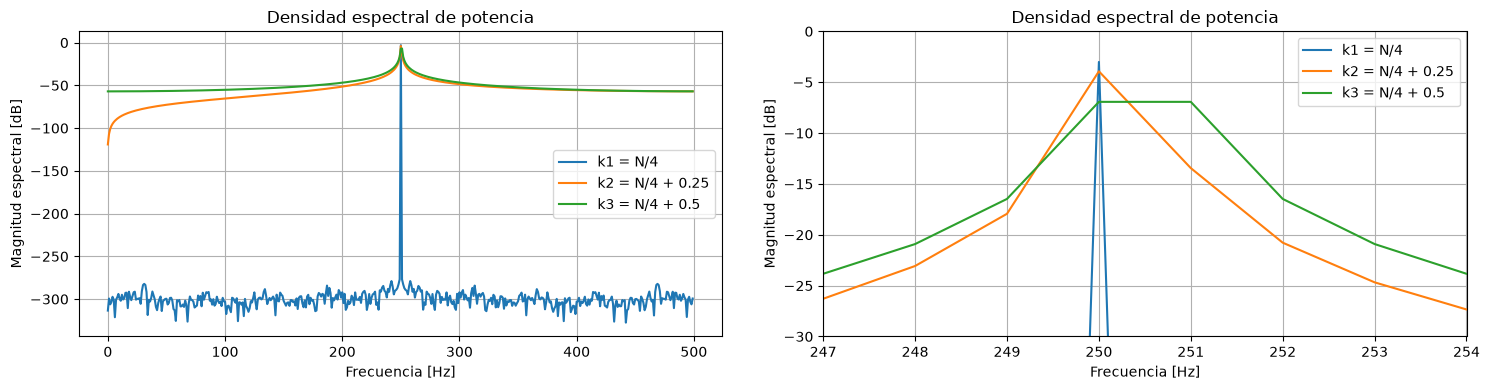

In [35]:
"_______________________________________ Main Script _______________________________________"

"Genero señales"
tt, xsen_1 = gen_sin (vmax, dc, k1*ff, ph, N, fs)
tt, xsen_2 = gen_sin (vmax, dc, k2*ff, ph, N, fs)
tt, xsen_3 = gen_sin (vmax, dc, k3*ff, ph, N, fs)

"Calculo la densidad de potencia en dB para cada señal"
pds_X1, pds_full_1 = PDS_calculator (xsen_1, N)
pds_X2, pds_full_2 = PDS_calculator (xsen_2, N)
pds_X3, pds_full_3 = PDS_calculator (xsen_3, N)

#Armo vector de frecuencias
frec = np.arange(N//2) * fs/N

"Grafico espectros de densidad de potencia"
fig, axs = plt.subplots(1, 2, figsize=(15, 4))

axs[0].plot(frec, pds_X1, label="k1 = N/4")
axs[0].plot(frec, pds_X2, label="k2 = N/4 + 0.25")
axs[0].plot(frec, pds_X3, label="k3 = N/4 + 0.5")

#Mismo gráfico pero con zoom en la sección que me interesa
axs[1].plot(frec, pds_X1, label="k1 = N/4")
axs[1].plot(frec, pds_X2, label="k2 = N/4 + 0.25")
axs[1].plot(frec, pds_X3, label="k3 = N/4 + 0.5")
axs[1].set_xlim(247,254)
axs[1].set_ylim(-30,0)

for ax in axs.flat:
    ax.set_title("Densidad espectral de potencia")
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel ('Magnitud espectral [dB]')
    ax.grid()
    ax.legend()

plt.tight_layout(w_pad=3)
plt.show()

## <u>Análisis</u>

Estoy comparando el espectro de potencias para 3 señales senoidales que solo difieren en su frecuencia. Apliqué a las 3 señales una DFT bins estan espaciados $Δf = 1Hz$, lo cual significa que, la 1era señal es la unica que no sufre desparramo de energía en su espectro de frecuencias, ya que toda su energía se encuentra concentrada en la frecuencia 250Hz, la cual coincide perfectamente con un bin de la DFT, y resulta en un espectro claramente concentrado en la frecuencia de la señal.

En contraste, las señales 2 y 3 sufren distorsiones visibles en sus respectivos espectros debido a que sus frecuencias estan desplazadas una cantidad no entera respecto a 250Hz, hay una discontinuidad en los extremos de la ventana temporal, lo cual significa que la densidad de potencia de la señal está concentrada en un valor de frecuencia por fuera de la grilla de bins establecida, y que la DFT representa distribuyendo esa potencia en varios coeficientes alrededor de la frecuencia real. Esto se observa como un pico de amplitud mucho mas ancho alrededor de $f=250Hz$ para las 2 señales. 

Es importante además destacar que las frecuencias de las señales 2 y 3, si bien están ambas corridas con respecto a los bines disponibles, resultan en diferentes grados de distorsión del espectro. Para $k_2=Δf.0,25$, el espectro muestra un pico definido predominante en 250Hz, con amplitudes decrecientes a cada lado de ese pico. Para $k_3=Δf.0,5$ un zoom a la zona de máxima magnitud muestra una especie de <i>meseta</i> de magnitud entre las frecuencias 250 y 251Hz antes de decrecer de forma casi asintótica hacia las frecuencias contíguas. Esto se da porque $f_2$, si bien desplazada se encuentra más próxima al bin $b=250$, mientras que $f_3$ cae en el exacto punto medio entre $b=250$ y $b=251$, por lo que la distorsión de su espectro es aún más evidente.

## Inciso $b)$

Busco verificar la potencia unitaria para cada espectro de densidad de potencia. Para esto usaré la identidad de Parceval, según la cual, la norma al cuadrado de una señal es igual a la suma de los cuadrados de sus coeficientes de Fourier:
<div align="center">$\sum_{n=0}^{N-1} |x[n]|^2=\frac{1}{N}\sum_{k=0}^{N-1} |X[k]|^2$</div>



In [15]:
"Comprobación de potencia unitaria con Parceval"
Pot_1 = np.sum(pds_full_1) / N**2
Pot_2 = np.sum(pds_full_2) / N**2
Pot_3 = np.sum(pds_full_3) / N**2

print("Potencia señal 1:", Pot_1)
print("Potencia señal 2:", Pot_2)
print("Potencia señal 3:", Pot_3)


Potencia señal 1: 1.0000000000000002e-06
Potencia señal 2: 9.989999999999995e-07
Potencia señal 3: 1.0000000000000004e-06


## <u>Análisis</u>

En los 3 casos, la potencia de la señal es unitaria. La identidad de Parseval permite comprobar que la energía total para cada señal sigue siendo la misma. El desparramo solo cambia cómo esa potencia está distribuído en el espectro frecuencial.

La señal 1 está perfectamente alineada con la grilla de binds de la DFT, por lo que concentra prácticamente toda su potencia en el bin 250. En contraste, para las señales 2 y 3, la DFT distribuye esa misma potencia total en un amplio rango de bins, pero en todos los casos, la potencia total de cada señal se mantiene independiente de su distribución espectral.

## Inciso $c)$

Debo usar la técnica de <i>zero padding</i> para agregar $9N$ zeros al final de cada una de las señales que generé para lograr un nuevo valor de Δf y ver cómo afecta esto a mis resultados anteriores.

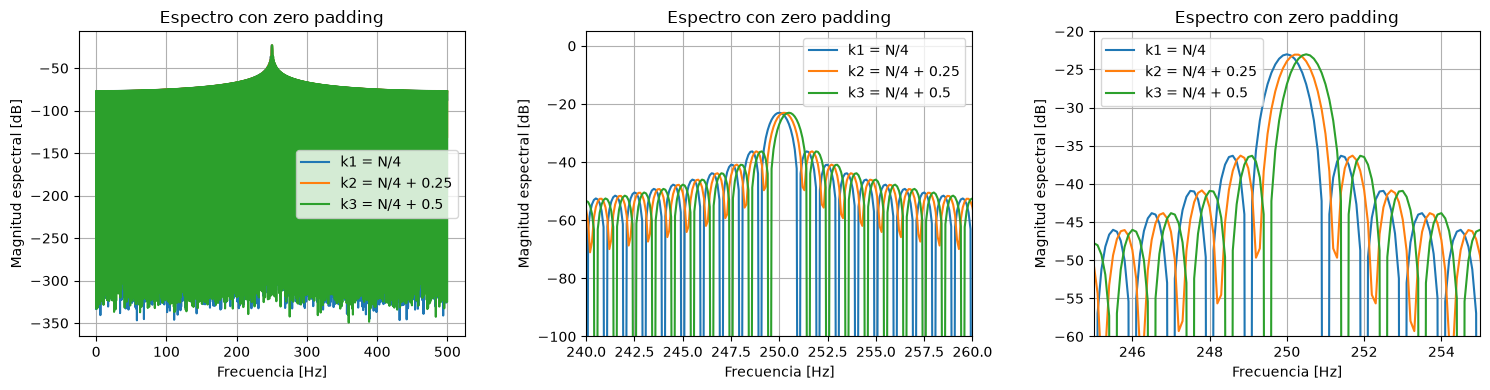

In [38]:
"Zero padding"
xsen_1_zpad = np.concatenate((xsen_1, np.zeros(9*N)))
xsen_2_zpad = np.concatenate((xsen_2, np.zeros(9*N)))
xsen_3_zpad = np.concatenate((xsen_3, np.zeros(9*N)))

#Obtengo el N' despues de concatenar con el vector de ceros
N_zpad = len(xsen_1_zpad)

#Transformo señales concatenadas
X1_zpad_dB, X1_zpad = PDS_calculator (xsen_1_zpad, N_zpad)
X2_zpad_dB, X2_zpad = PDS_calculator (xsen_2_zpad, N_zpad)
X3_zpad_dB, X3_zpad = PDS_calculator (xsen_3_zpad, N_zpad)

#Nuevo eje de frecuencias
frec_zpad = np.arange(N_zpad//2) * fs/N_zpad

"Grafico espectros de densidad de potencia"
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(frec_zpad, X1_zpad_dB, label="k1 = N/4")
axs[0].plot(frec_zpad, X2_zpad_dB, label="k2 = N/4 + 0.25")
axs[0].plot(frec_zpad, X3_zpad_dB, label="k3 = N/4 + 0.5")

#Mismo gráfico pero con zoom en la sección que me interesa
axs[1].plot(frec_zpad, X1_zpad_dB, label="k1 = N/4")
axs[1].plot(frec_zpad, X2_zpad_dB, label="k2 = N/4 + 0.25")
axs[1].plot(frec_zpad, X3_zpad_dB, label="k3 = N/4 + 0.5")
axs[1].set_xlim(240,260)
axs[1].set_ylim(-100,5)

axs[2].plot(frec_zpad, X1_zpad_dB, label="k1 = N/4")
axs[2].plot(frec_zpad, X2_zpad_dB, label="k2 = N/4 + 0.25")
axs[2].plot(frec_zpad, X3_zpad_dB, label="k3 = N/4 + 0.5")
axs[2].set_xlim(245,255)
axs[2].set_ylim(-60,-20)

for ax in axs.flat:
    ax.set_title("Espectro con zero padding")
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel ('Magnitud espectral [dB]')
    ax.grid()
    ax.legend()

plt.tight_layout(w_pad=3)
plt.show()

## <u>Análisis</u>

Para $N=1000$ muestras, la resolución frecuencial $\frac{f_s}{N}=Δf$ resulta $=1Hz$; pero con la cantidad de muestras agregadas mediante zero padding, $N'=10000$ y $Δf'=0,1Hz$. Entonces, la grilla de la DFT que antes contaba con una separación de $Δf=1Hz$ entre bins consecutivos, ahora es de $Δf'=0.1Hz$ <u> para el mismo rango de frecuencias </u>, es decir, al agregar 9N zeros al final de cada señal, conseguí aumentar la densidad de la grilla espectral de frecuencias. Estoy viendo con mayor detalle el espectro original

Algo que salta a la vista inmediatamente son los patrones de lóbulos observados para el espectro de cada señal. Estos patrones superpuestos corresponden a la transformada de la ventana rectangular implícita aplicada a las señales. 

Para la señal 1, la frecuencia de 250 Hz coincidía exactamente con uno de los bins de la DFT original. Debido a esto, los bins de la DFT coincidían con el máximo del lóbulo principal, y con los ceros de los lóbulos laterales, lo cual resultaba en la aparente concentración absoluta de la energía en 250 Hz con mínimo desparramo espectral.

Para las señales 2 y 3, que se encontraban más significativamente desplazadas con respecto a la grilla de bins originales, el desparramo ya podía observarse debido a que la energía de la senoide no queda concentrada en un único bin. Con zero padding, este mismo fenómeno se observa con mayor detalle y se puede apreciar mejor la forma de la envolvente espectral.

Por lo tanto, la tecnica zero padding permite aumentar la densidad de la grilla espectral de la DFT, pero no modifica su resolución espectral ni agrega información a la señal. Solo aumenta la cantidad de bins en el mismo rango de frecuencias, permitiendo visualizar con mayor detalle el espectro que ya estaba determinado por la señal finita y la ventana implícita.